# Used-Car Price Prediction (India, 2025–2026): analysis and modelling

**Goal:** predict the asking price (in lakhs of rupees) of a used car from its brand, model, **variant**, age,
kilometres, fuel, gearbox, owners and the platform it is listed on.

**Type of problem:** supervised *regression* (the answer is a number).

**Data:** 40,440 listings from CarDekho, Cars24 and Spinny, collected in 2025 and 2026 (four public Kaggle
datasets, see `DATA_SOURCES.md`), merged by `python build_dataset.py` into `data/used_cars_india.csv`.

**Sections**

1. The sources and how they were merged
2. Data quality checks
3. Exploratory data analysis
4. Features (including the variant)
5. Comparing 9 algorithms with cross-validation
6. Does the variant help? (an ablation)
7. Tuning
8. The final exam on unseen cars
9. What the model learned
10. An honest price range
11. The deployed model in action

The reusable code lives in the `carprice/` package, so the API and the website use exactly the same logic.

In [1]:
import sys, json, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_predict, cross_validate, train_test_split

from carprice.config import CV_FOLDS, RANDOM_STATE, TEST_SIZE, BUILD_REPORT_PATH
from carprice.data import TARGET, build_features, load_clean
from carprice.evaluate import error_by_price_band, regression_metrics
from carprice.modeling import SEARCH_SPACES, apply_interval, candidate_models, make_pipeline
from carprice.sources import split_brand, variant_key

pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})

## 1. The sources and how they were merged

In [2]:
report = json.loads(BUILD_REPORT_PATH.read_text())
pd.DataFrame(report["sources"]).T

,dataset,platform,collected,rows_read
cardekho_2026,sumangoudakaggle/second-hand-car-dataset-cardekho,CarDekho,2026,13361
spinny_2025,abhiramasdf/indian-used-cars-dataset,Spinny,2025,8095
cars24_2025,sukhmansaran/used-cars-prices-cars-24,Cars24,2025,8839
cardekho_2025,pankajmaulekhi/indian-second-hand-cars-dataset,CarDekho,2025,10145


In [3]:
pd.Series(report['counts'], name='rows')

rows_read                         40440
dropped_unknown_brand_or_model      188
dropped_missing_values              340
dropped_unknown_transmission          0
dropped_lpg                          37
dropped_price_outliers               11
dropped_kms_outliers                 66
dropped_impossible_years              0
dropped_rare_fuels                   53
dropped_duplicates                 2826
rows_kept                         36919
Name: rows, dtype: int64

Each source writes cars differently, so the builder harmonises them:

* brands: `Maruti`, `MARUTI` and `Maruti Suzuki` are one brand;
* models: `Wagon R 1.0`, `New Wagon R` and `Wagon R` are one model;
* variants: word order, case, punctuation, fuel words and emission badges are ignored, so these are one variant:

In [4]:
for text in ["ZXi Plus AMT", "zxi-plus-amt", "ZXI+ AMT Petrol", "AMT ZXI Plus BSVI"]:
    print(f"{text:22s} -> {variant_key(text, 'Swift')!r}")
print(split_brand("MARUTI Wagon R 1.0"), split_brand("Landrover Discovery Sport"))

ZXi Plus AMT           -> 'amt plus zxi'
zxi-plus-amt           -> 'amt plus zxi'
ZXI+ AMT Petrol        -> 'amt plus zxi'
AMT ZXI Plus BSVI      -> 'amt plus zxi'
('Maruti Suzuki', 'Wagon R 1.0') ('Land Rover', 'Discovery Sport')


**Duplicates:** 2,826 listings were the same car twice (for example a CarDekho listing shown under several cities).
They are removed **before** splitting into training and test data; otherwise the model could be tested on cars it
had already seen, and the score would look better than it really is.

## 2. Data quality checks

In [5]:
df, info = load_clean()
print(df.shape)
df.head()

(36919, 15)


,Source,Platform,Listing_Year,Brand,Model,Variant,Variant_Key,Name,Year,Kms_Driven,Fuel_Type,Transmission,Owner,City,Selling_Price
0,cardekho_2025,CarDekho,2025,Ashok Leyland,Stile,LE 7 SEATER,7 le seater,Ashok Leyland Stile LE 7 SEATER,2014,100000,Diesel,Manual,1,Ranga Reddy,3.00
1,cardekho_2025,CarDekho,2025,Ashok Leyland,Stile,LX OPTIONAL,lx o,Ashok Leyland Stile LX OPTIONAL,2015,1000,Diesel,Manual,3,,9.00
2,cardekho_2026,CarDekho,2026,Aston Martin,DB11,V12,v12,Aston Martin DB11 V12,2017,4700,Petrol,Automatic,1,Kolkata,239.00
3,cardekho_2026,CarDekho,2026,Aston Martin,Rapide,S V12,s v12,Aston Martin Rapide S V12,2017,7000,Petrol,Automatic,0,Nashik,250.00
4,cardekho_2026,CarDekho,2026,Audi,A3,35 TDI PREMIUM PLUS,35 plus premium tdi,Audi A3 35 TDI PREMIUM PLUS,2014,74000,Diesel,Automatic,0,Hyderabad,12.99


In [6]:
print("Missing values:", info["missing_values"])
print("Rows with a variant:", f"{(df.Variant_Key != '').mean():.1%}")
print("Brands / models / variants:", info["brands"], info["models"], info["variants"])
print("\nRows by platform:\n", df.Platform.value_counts().to_string())
print("\nRows by fuel:\n", df.Fuel_Type.value_counts().to_string())
print("\nCars registered 2020 or later:\n", df.loc[df.Year >= 2020, "Year"].value_counts().sort_index().to_string())

Missing values: 0
Rows with a variant: 99.8%
Brands / models / variants: 38 424 5103

Rows by platform:
 Platform
CarDekho    22409
Cars24       8775
Spinny       5735

Rows by fuel:
 Fuel_Type
Petrol      23783
Diesel      11992
CNG           921
Electric      223

Cars registered 2020 or later:
 Year
2020    2366
2021    3463
2022    3974
2023    2919
2024    1707
2025     411
2026      12


* No missing values, and nearly every listing has its exact variant.
* Cars are registered up to 2026. Very new cars (2025–2026) are few, simply because few such cars are for sale
  second-hand yet (section 8 checks how well they are predicted).
* LPG cars were removed on request, and hybrids were dropped because there were too few of them to learn from.

## 3. Exploratory data analysis

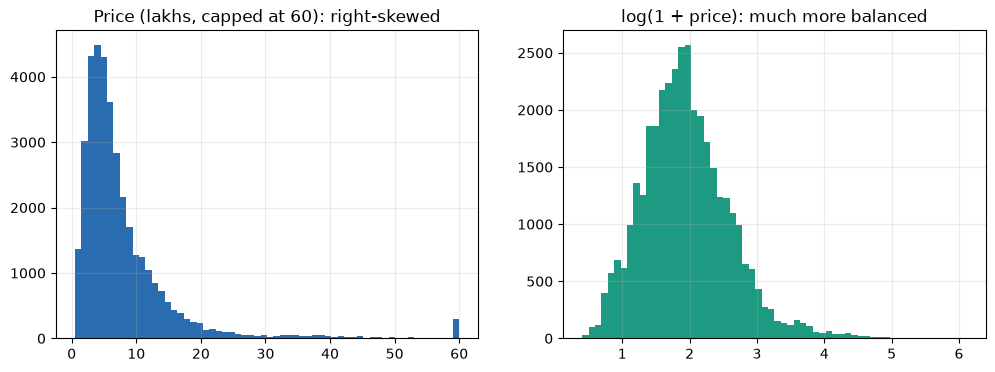

count    36919.00
mean         8.23
std         11.14
min          0.50
25%          3.53
50%          5.66
75%          9.30
max        450.00
Name: Selling_Price, dtype: float64

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[TARGET].clip(upper=60), bins=60, color="#2b6cb0"); axes[0].set_title("Price (lakhs, capped at 60): right-skewed")
axes[1].hist(np.log1p(df[TARGET]), bins=60, color="#1f9a82"); axes[1].set_title("log(1 + price): much more balanced")
plt.show()
df[TARGET].describe().round(2)

**Decision:** the model learns `log(1 + price)`, so it thinks in percentages (depreciation is a percentage) and a few luxury cars don't dominate.

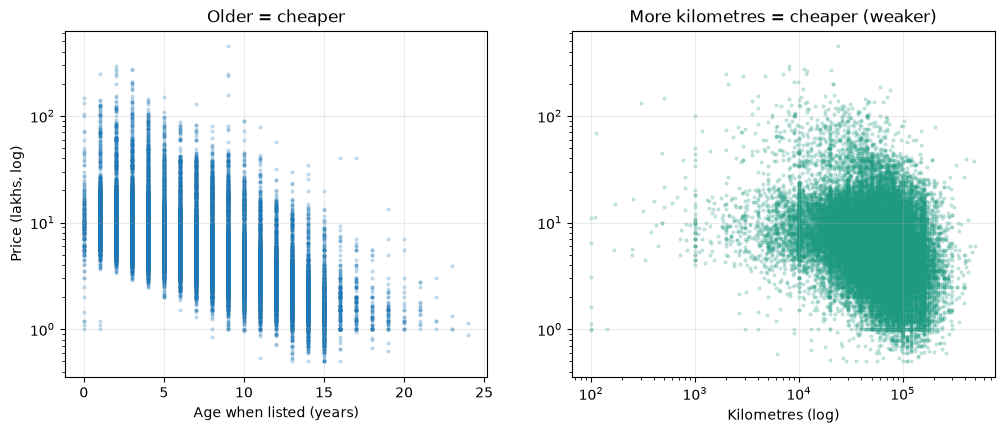

Rank correlation with price:
Age     -0.68
Kms     -0.34
Owner   -0.33
Price    1.00


In [8]:
age = (df.Listing_Year - df.Year).clip(lower=0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(age, df[TARGET], s=4, alpha=0.2); axes[0].set_yscale("log")
axes[0].set_xlabel("Age when listed (years)"); axes[0].set_ylabel("Price (lakhs, log)"); axes[0].set_title("Older = cheaper")
axes[1].scatter(df.Kms_Driven.clip(lower=100), df[TARGET], s=4, alpha=0.2, color="#1f9a82"); axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set_xlabel("Kilometres (log)"); axes[1].set_title("More kilometres = cheaper (weaker)")
plt.show()
print("Rank correlation with price:")
print(pd.DataFrame({"Age": age, "Kms": df.Kms_Driven, "Owner": df.Owner, "Price": df[TARGET]}).corr(method="spearman")["Price"].round(2).to_string())

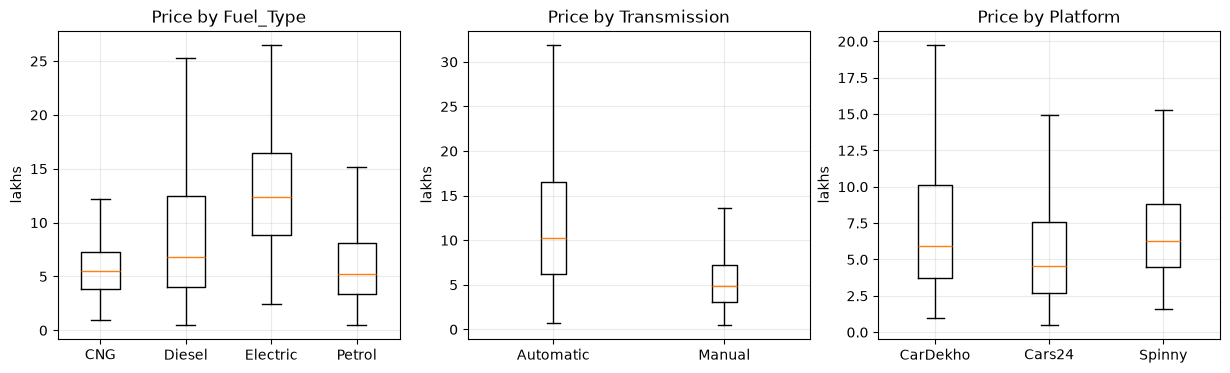

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for axis, column in zip(axes, ["Fuel_Type", "Transmission", "Platform"]):
    groups = [(str(k), g[TARGET].values) for k, g in df.groupby(column)]
    axis.boxplot([v for _, v in groups], tick_labels=[k for k, _ in groups], showfliers=False)
    axis.set_title(f"Price by {column}"); axis.set_ylabel("lakhs")
plt.show()

* Diesel, electric and automatic cars fetch more.
* The platforms' median prices differ, but mostly because they sell different cars (Cars24 lists many older,
  high-kilometre cars; Spinny mostly newer, popular ones). That is why the model looks at the platform **together
  with** everything else: for the *same* car, section 11 shows the platform moves the price only a few percent.

### Does the variant matter? A Maruti Swift example

In [10]:
swift = df[(df.Brand == "Maruti Suzuki") & (df.Model == "Swift") & df.Year.between(2018, 2020) & (df.Fuel_Type == "Petrol")]
common = swift.Variant.value_counts().head(6).index
swift[swift.Variant.isin(common)].groupby("Variant")[TARGET].agg(["count", "median"]).sort_values("median").round(2)

,count,median
Variant,,
LXI,35,4.49
VXI,76,5.00
ZXI PLUS,10,5.12
VXI AMT,38,5.26
ZXI AMT,28,5.46
ZXI,12,5.50


For cars of the same age and fuel, the top variants ask noticeably more than the base ones, so the variant carries real information.

## 4. Features

| Feature | Meaning |
|---|---|
| `Age` | listing year minus registration year (never below 0) |
| `Kms_Driven`, `Log_Kms`, `Kms_Per_Year` | odometer, its logarithm, and how hard the car was used |
| `Owner` | previous owners, 0–3 |
| `Brand`, `Model` | one-hot **and** target-encoded ("how expensive are cars like this?") |
| `Trim` | the exact variant (`Maruti Suzuki|Swift|vxi`), target-encoded |
| `Variant_Key` | the variant's words (`amt`, `plus`, `turbo`…) as yes/no columns, so rare variants are still understood |
| `Fuel_Type`, `Transmission`, `Platform` | one-hot |

Target encoding is cross-fitted inside scikit-learn, so it never sees the price it is trying to predict.

In [11]:
X = build_features(df)
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
cv = KFold(CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print("train:", X_train.shape, "test:", X_test.shape)
X.head()

train: (29535, 12) test: (7384, 12)


,Age,Kms_Driven,Log_Kms,Kms_Per_Year,Owner,Brand,Model,Trim,Variant_Key,Fuel_Type,Transmission,Platform
0,11.0,100000.0,11.512935,9090.909091,1.0,Ashok Leyland,Stile,Ashok Leyland|Stile|7 le seater,7 le seater,Diesel,Manual,CarDekho
1,10.0,1000.0,6.908755,100.000000,3.0,Ashok Leyland,Stile,Ashok Leyland|Stile|lx o,lx o,Diesel,Manual,CarDekho
2,9.0,4700.0,8.455531,522.222222,1.0,Aston Martin,DB11,Aston Martin|DB11|v12,v12,Petrol,Automatic,CarDekho
3,9.0,7000.0,8.853808,777.777778,0.0,Aston Martin,Rapide,Aston Martin|Rapide|s v12,s v12,Petrol,Automatic,CarDekho
4,12.0,74000.0,11.211834,6166.666667,0.0,Audi,A3,Audi|A3|35 plus premium tdi,35 plus premium tdi,Diesel,Automatic,CarDekho


## 5. Comparing 9 algorithms (5-fold cross-validation on the training data)

In [12]:
def median_ape(estimator, X, y):
    return -float(np.median(np.abs(estimator.predict(X) - y) / y))

scoring = {"r2": "r2", "mae": "neg_mean_absolute_error", "medape": median_ape}
rows = []
for name, estimator in candidate_models().items():
    result = cross_validate(make_pipeline(estimator), X_train, y_train, cv=cv, scoring=scoring, return_train_score=True, n_jobs=1)
    rows.append({"Algorithm": name, "CV error MAE (lakh)": -result["test_mae"].mean(), "CV R2": result["test_r2"].mean(),
                 "CV typical error %": -result["test_medape"].mean() * 100, "Train R2": result["train_r2"].mean()})
comparison = pd.DataFrame(rows).sort_values("CV error MAE (lakh)").reset_index(drop=True)
comparison.round(3)

,Algorithm,CV error MAE (lakh),CV R2,CV typical error %,Train R2
0,Extra Trees,1.166,0.820,10.390,0.921
1,Random Forest,1.206,0.819,10.763,0.924
2,Hist Gradient Boosting,1.254,0.808,10.871,0.872
3,Ridge Regression,1.360,0.777,11.232,0.904
4,Linear Regression,1.363,0.777,11.265,0.897
5,K-Nearest Neighbours,1.382,0.777,11.915,0.903
6,Gradient Boosting,1.415,0.784,12.755,0.884
7,Decision Tree,1.583,0.741,14.095,0.928
8,Baseline (median price),4.739,-0.054,45.904,-0.053


* Every model beats the do-nothing baseline by a wide margin.
* Tree ensembles (Extra Trees, Random Forest, boosted trees) lead. Linear models have about 15% more error: with
  400+ models, 5,000 variants and three platforms the effects interact (a diesel premium is not the same for a
  hatchback and an SUV), which trees capture and a straight line cannot.
* A big gap between **Train R²** and **CV R²** would mean memorising; compare the rows.

## 6. Does the variant help? (ablation)

In [13]:
from sklearn.ensemble import ExtraTreesRegressor
without_variant = X_train.assign(Trim=X_train.Brand + "|" + X_train.Model + "|", Variant_Key="")
est = ExtraTreesRegressor(n_estimators=80, min_samples_leaf=3, max_features=0.5, n_jobs=-1, random_state=RANDOM_STATE)
for label, data in [("with variant", X_train), ("without variant", without_variant)]:
    r = cross_validate(make_pipeline(est), data, y_train, cv=cv, scoring=scoring)
    print(f"{label:16s} MAE {-r['test_mae'].mean():.3f} lakh   typical error {-r['test_medape'].mean()*100:.1f}%")

with variant     MAE 1.181 lakh   typical error 10.4%


without variant  MAE 1.246 lakh   typical error 11.2%


Knowing the variant lowers the error: this is exactly why the new data was chosen.

## 7. Tuning

`python train.py` tunes the three best tunable algorithms with a random search (20 settings each, graded by 5-fold
cross-validation) and keeps the most accurate model **whose saved file is at most 40 MB**, so it can be shared on
GitHub and loads quickly. The chosen settings are recorded in `models/metadata.json`:

In [14]:
meta = json.loads(Path("../models/metadata.json").read_text())
print("Winner:", meta["model_name"], f"({meta['model_size_mb']} MB)")
print({key.replace("regressor__model__", ""): value for key, value in meta["model_params"].items()})
pd.DataFrame(meta["comparison"])[["model", "cv_mae", "cv_r2", "cv_medape", "test_mae", "test_r2", "size_mb"]].round(3)

Winner: Hist Gradient Boosting (tuned) (2.39 MB)
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 1000, 'learning_rate': 0.05, 'l2_regularization': 1.0}


,model,cv_mae,cv_r2,cv_medape,test_mae,test_r2,size_mb
0,Extra Trees,1.166,0.820,10.390,1.145,0.867,110.1
1,Extra Trees (tuned),1.168,0.820,10.373,1.148,0.867,73.5
2,Hist Gradient Boosting (tuned),1.190,0.818,10.284,1.137,0.863,2.4
3,Random Forest,1.206,0.819,10.763,1.163,0.872,NaN
4,Random Forest (tuned),1.208,0.819,10.796,1.166,0.873,NaN
5,Hist Gradient Boosting,1.254,0.808,10.871,1.212,0.851,NaN
6,Ridge Regression,1.360,0.777,11.232,1.361,0.787,NaN
7,Linear Regression,1.363,0.777,11.265,1.362,0.784,NaN
8,K-Nearest Neighbours,1.382,0.777,11.915,1.333,0.841,NaN
9,Gradient Boosting,1.415,0.784,12.755,1.394,0.803,NaN


## 8. The final exam: the untouched test set

In [15]:
from carprice.training import _build
name = meta["model_name"].replace(" (tuned)", "")
best = _build(name, meta["model_params"] or None)
fitted = clone(best).fit(X_train, y_train)
test_pred = fitted.predict(X_test)
pd.Series(regression_metrics(y_test, test_pred), name="test set").round(3).to_frame()

,test set
r2,0.863
mae,1.137
rmse,4.117
mape,13.779
median_ape,9.783
within_10pct,50.894
within_20pct,78.616
r2_log,0.946


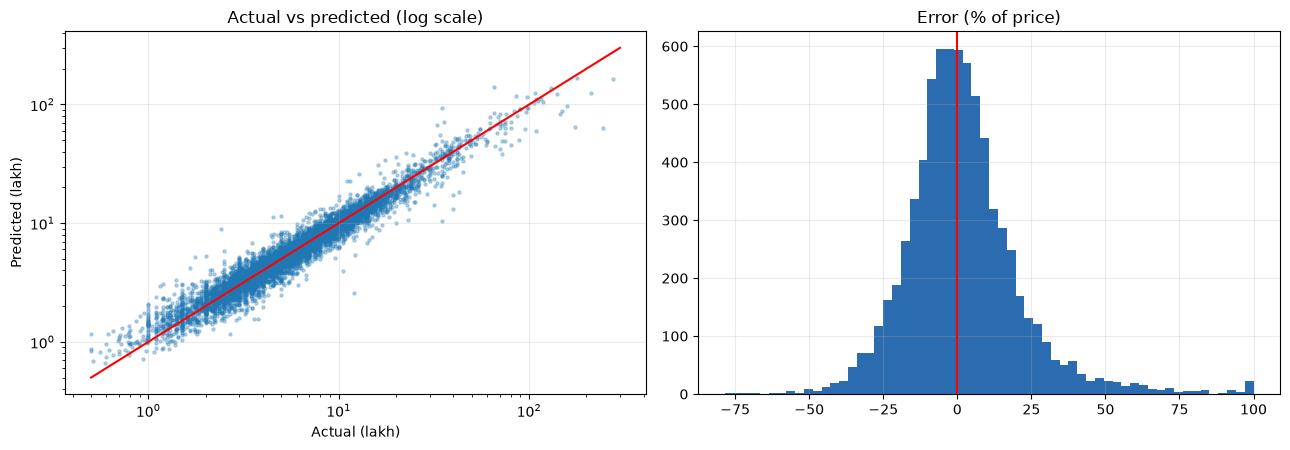

,band,cars,mae,median_ape
0,under 2 L,507,0.36,19.11
1,2 to 5 L,2568,0.50,11.38
2,5 to 10 L,2676,0.76,8.34
3,10 to 20 L,1239,1.52,8.35
4,over 20 L,394,7.67,11.48


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].scatter(y_test, test_pred, s=5, alpha=0.3); axes[0].plot([0.5, 300], [0.5, 300], "r-")
axes[0].set_xscale("log"); axes[0].set_yscale("log"); axes[0].set_xlabel("Actual (lakh)"); axes[0].set_ylabel("Predicted (lakh)")
axes[0].set_title("Actual vs predicted (log scale)")
pct = (test_pred - y_test) / y_test * 100
axes[1].hist(pct.clip(-100, 100), bins=60, color="#2b6cb0"); axes[1].axvline(0, color="r"); axes[1].set_title("Error (% of price)")
plt.tight_layout(); plt.show()
pd.DataFrame(error_by_price_band(y_test, test_pred)).round(2)

In [17]:
test = df.loc[X_test.index].assign(pred=test_pred)
test["ape"] = (test.pred - test[TARGET]).abs() / test[TARGET] * 100
print("Typical error by platform:"); print(test.groupby("Platform").ape.median().round(1).to_string())
for label, mask in [("registered 2023 or later", test.Year >= 2023), ("over 20 lakh", test[TARGET] > 20), ("electric", test.Fuel_Type == "Electric")]:
    print(f"Typical error, {label}: {test.loc[mask, 'ape'].median():.1f}%  ({mask.sum()} cars)")

Typical error by platform:
Platform
CarDekho    11.2
Cars24      11.5
Spinny       5.5
Typical error, registered 2023 or later: 7.5%  (996 cars)
Typical error, over 20 lakh: 11.5%  (384 cars)
Typical error, electric: 16.6%  (46 cars)


Newer cars are predicted *better* than average (they are more uniform). Luxury and electric cars are harder: they are
rare and vary more, so the website adds a warning to their estimates.

## 9. What did the model learn? (permutation importance)

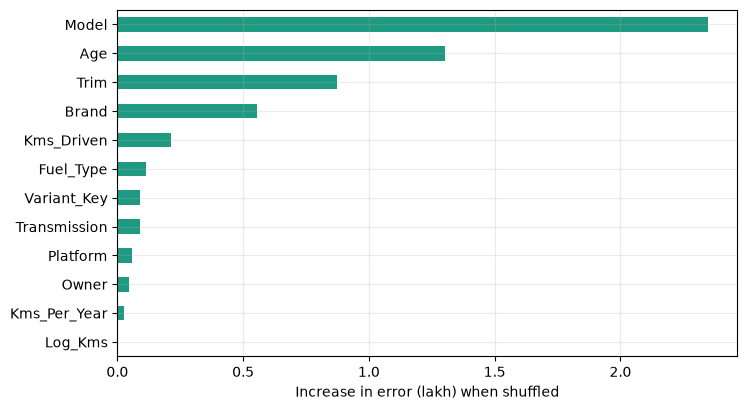

In [18]:
importance = permutation_importance(fitted, X_test, y_test, scoring="neg_mean_absolute_error", n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
pd.Series(importance.importances_mean, index=X_test.columns).sort_values().plot.barh(figsize=(8, 4.5), color="#1f9a82")
plt.xlabel("Increase in error (lakh) when shuffled"); plt.show()

Which car it is (model, brand, the exact variant) and how old it is explain most of the price. Several inputs
overlap (brand, model, trim; the three kilometre features), so each one looks smaller on its own than their
combined effect.

## 10. An honest price range

In [19]:
oof = cross_val_predict(clone(best), X_train, y_train, cv=cv)
log_errors = np.log1p(y_train.to_numpy()) - np.log1p(oof)
low_q, high_q = np.quantile(log_errors, [0.10, 0.90])
lower, upper = apply_interval(test_pred, low_q, high_q)
coverage = ((y_test.to_numpy() >= lower) & (y_test.to_numpy() <= upper)).mean()
print(f"Range: about {np.expm1(low_q)*100:+.0f}% to {np.expm1(high_q)*100:+.0f}% around the prediction")
print(f"Test cars inside the range: {coverage:.1%} (promised 80%)")

Range: about -16% to +19% around the prediction
Test cars inside the range: 81.0% (promised 80%)


## 11. The deployed model in action

In [20]:
from carprice.predictor import get_predictor
predictor = get_predictor()
base = dict(Year=2020, Kms_Driven=45000, Fuel_Type="Petrol", Transmission="Manual", Owner=0, Platform="CarDekho")
cars = [("Maruti Suzuki Swift", "LXI"), ("Maruti Suzuki Swift", "VXI"), ("Maruti Suzuki Swift", "ZXI PLUS"),
        ("Hyundai Creta", "SX"), ("Kia Seltos", "HTK PLUS G"), ("Toyota Innova Crysta", None)]
results = predictor.predict_many([{**base, "Car_Name": name, "Variant": variant} for name, variant in cars])
pd.DataFrame({"car": [r["matched_car"] for r in results], "estimate (lakh)": [r["price"] for r in results],
              "range": [f"{r['lower']:.2f} to {r['upper']:.2f}" for r in results]})

,car,estimate (lakh),range
0,Maruti Suzuki Swift LXI,4.69,3.77 to 5.79
1,Maruti Suzuki Swift VXI,5.16,4.17 to 6.36
2,Maruti Suzuki Swift ZXI PLUS,5.95,4.83 to 7.30
3,Hyundai Creta SX,10.15,8.35 to 12.31
4,Kia Seltos HTK PLUS G,8.93,7.32 to 10.85
5,Toyota Innova Crysta,14.19,11.74 to 17.13


In [21]:
platforms = predictor.predict_many([{**base, "Car_Name": "Hyundai Creta", "Variant": "SX", "Platform": p} for p in ["CarDekho", "Cars24", "Spinny"]])
pd.Series({p: r["price"] for p, r in zip(["CarDekho", "Cars24", "Spinny"], platforms)}, name="Hyundai Creta SX 2020 (lakh)")

CarDekho    10.15
Cars24       9.90
Spinny      10.52
Name: Hyundai Creta SX 2020 (lakh), dtype: float64

## Conclusions

* With recent (2025–2026) data that includes the **variant**, the model's typical error on unseen cars is about
  10%, down from about 15% with the old 2020 data, and its 80% price range is honest.
* The car itself (model, brand, exact variant) and its age drive the price; the platform shifts it by only a few percent.
* Removing duplicates before splitting and predicting log-price were essential; adding the variant was the
  single biggest improvement.

## Limitations and next steps

* Asking prices, not final sale prices; no information on accidents, condition or servicing.
* Snapshots from 2025–2026: prices drift, so the data should be refreshed and the model retrained periodically
  (`python build_dataset.py && python train.py`).
* Luxury (over ₹20 lakh) and electric cars are rare and vary more: their typical error is higher and the price
  range holds only about 2 times in 3, so the website warns about them.
* Ideas: add city as a feature, engine power from the CarDekho specifications, and gradient-boosting libraries
  such as LightGBM.